# Импорты библиотек

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn

Архитектура модели UNet

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        b = self.bottleneck(self.pool(x4))

        x = self.up4(b)
        x = torch.cat([x, x4], dim=1)
        x = self.up_conv4(x)

        x = self.up3(x)
        x = torch.cat([x, x3], dim=1)
        x = self.up_conv3(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up_conv2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up_conv1(x)

        return self.out_conv(x)

# Инициализация и загрузка весов

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Инициализирую пустую архитектуру
model = UNet(in_channels=3, out_channels=1)

# Загружаю обученные веса
weights_path = "unet_nails_model.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))

# Отправляю на процессор и перевожу в режим оценки (Inference)
model.to(device)
model.eval()
print("Модель успешно загружена и готова к работе!")

Используемое устройство: cpu
Модель успешно загружена и готова к работе!


# Загрузка и предобработка фото

In [ ]:
image_path = "my_nails.jpg"
original_image = cv2.imread(image_path)

original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

target_size = (256, 256)
resized_image = cv2.resize(original_image, target_size)

# Перевожу фото в формат для  pytorch
image_tensor = resized_image.astype(np.float32) / 255.0
image_tensor = np.transpose(image_tensor, (2, 0, 1))
image_tensor = torch.tensor(image_tensor).unsqueeze(0).to(device)

print(f"Размер тензора для нейросети: {image_tensor.shape}")

Размер тензора для нейросети: torch.Size([1, 3, 256, 256])


# Предсказание

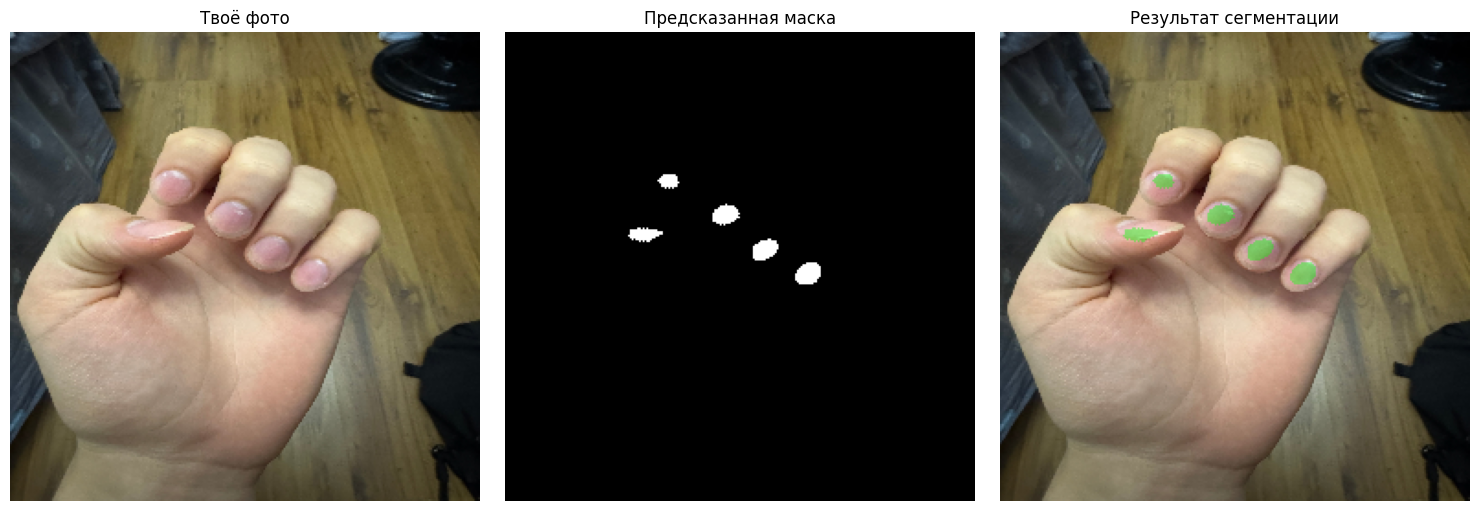

In [ ]:
with torch.no_grad():
    output = model(image_tensor)
    # Применяем сигмоиду для перевода значений в вероятности [0, 1]
    probs = torch.sigmoid(output).squeeze().cpu().numpy()

    # Создаем бинарную маску: всё, что выше порога 0.5 — это 1 (ноготь), остальное — 0
    mask = (probs > 0.5).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Твоё фото")
plt.imshow(resized_image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Предсказанная маска")
plt.imshow(mask, cmap="gray")
plt.axis("off")

overlay = resized_image.copy()
overlay[mask == 1] = [0, 255, 0]
dst = cv2.addWeighted(resized_image, 0.6, overlay, 0.4, 0)

plt.subplot(1, 3, 3)
plt.title("Результат сегментации")
plt.imshow(dst)
plt.axis("off")

plt.tight_layout()
plt.show()